### Load Dataset

In [1]:
import pandas as pd

df = pd.read_csv('Smartphone_Usage_Productivity_Dataset_50000.csv')

### Lakukan Exploratory Data Analysis (EDA)

In [2]:
from  IPython.display import display

print (f'Print 5 data teratas \n {display(df.head())} \n')
print (f'Informasi Dataset \n {df.info()} \n')
print (f'Cek Tipe Data \n {df.dtypes} \n')

,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
0,U1,58,Male,Professional,Android,1.3,6.7,6,8.8,4,42,1,8.7
1,U2,25,Male,Professional,Android,1.2,1.5,5,6.4,1,51,3,5.1
2,U3,19,Male,Student,iOS,5.3,5.7,5,9.0,4,14,5,6.3
3,U4,35,Female,Business Owner,iOS,5.8,2.5,2,5.7,3,36,6,12.8
4,U5,33,Male,Freelancer,Android,7.9,1.3,4,5.7,3,37,5,9.9


Print 5 data teratas 
 None 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    50000 non-null  object 
 1   Age                        50000 non-null  int64  
 2   Gender                     50000 non-null  object 
 3   Occupation                 50000 non-null  object 
 4   Device_Type                50000 non-null  object 
 5   Daily_Phone_Hours          50000 non-null  float64
 6   Social_Media_Hours         50000 non-null  float64
 7   Work_Productivity_Score    50000 non-null  int64  
 8   Sleep_Hours                50000 non-null  float64
 9   Stress_Level               50000 non-null  int64  
 10  App_Usage_Count            50000 non-null  int64  
 11  Caffeine_Intake_Cups       50000 non-null  int64  
 12  Weekend_Screen_Time_Hours  50000 non-null  float64
dtypes: float64(4), i

### Cek Missing Values

In [3]:
print (f'Cek Missing Value \n {df.isnull().sum()} \n')

Cek Missing Value 
 User_ID                      0
Age                          0
Gender                       0
Occupation                   0
Device_Type                  0
Daily_Phone_Hours            0
Social_Media_Hours           0
Work_Productivity_Score      0
Sleep_Hours                  0
Stress_Level                 0
App_Usage_Count              0
Caffeine_Intake_Cups         0
Weekend_Screen_Time_Hours    0
dtype: int64 



### Cleansing Data

In [4]:
df = df.drop(columns=["User_ID"]) # hapus kolom user_id karena tidak relevan untuk prediksi

### Cek Kewarasan Data

In [5]:
import pandas as pd
from IPython.display import display

def sanity_check(df: pd.DataFrame):
    rules = [
        ("Age <= 0", df["Age"] <= 0),
        ("Gender bukan Male/Female", ~df["Gender"].isin(["Male", "Female", "Other"])),
        ("Daily_Phone_Hours di luar 0–24", ~df["Daily_Phone_Hours"].between(0, 24)),
        ("Social_Media_Hours di luar > Daily_Phone_Hours", df["Social_Media_Hours"] > df["Daily_Phone_Hours"]),
        ("Sleep_Hours di luar 0–24", ~df["Sleep_Hours"].between(0, 24)),
    ]

    summary = []
    n = len(df)

    for i, (name, mask) in enumerate(rules, start=1):
        count = int(mask.sum())
        pct = (count / n * 100) if n else 0
        print(f"{i}. {name}: {count} ({pct:.2f}%)")
        summary.append({"check": name, "invalid_count": count, "invalid_pct": round(pct, 2)})

    return pd.DataFrame(summary)

summary_df = sanity_check(df)
display(summary_df)

1. Age <= 0: 0 (0.00%)
2. Gender bukan Male/Female: 0 (0.00%)
3. Daily_Phone_Hours di luar 0–24: 0 (0.00%)
4. Social_Media_Hours di luar > Daily_Phone_Hours: 14654 (29.31%)
5. Sleep_Hours di luar 0–24: 0 (0.00%)


,check,invalid_count,invalid_pct
0,Age <= 0,0,0.00
1,Gender bukan Male/Female,0,0.00
2,Daily_Phone_Hours di luar 0–24,0,0.00
3,Social_Media_Hours di luar > Daily_Phone_Hours,14654,29.31
4,Sleep_Hours di luar 0–24,0,0.00


In [6]:
from IPython.display import display

print (f' 5 row social media hours > daily phone hours \n {display(df[df["Social_Media_Hours"] > df["Daily_Phone_Hours"]].head())} \n')

,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
0,58,Male,Professional,Android,1.3,6.7,6,8.8,4,42,1,8.7
1,25,Male,Professional,Android,1.2,1.5,5,6.4,1,51,3,5.1
2,19,Male,Student,iOS,5.3,5.7,5,9.0,4,14,5,6.3
6,26,Male,Student,iOS,5.6,6.1,8,6.7,3,5,3,2.9
14,23,Male,Professional,Android,1.1,2.5,3,5.3,8,29,5,9.2


 5 row social media hours > daily phone hours 
 None 



### Cek Data Outlier

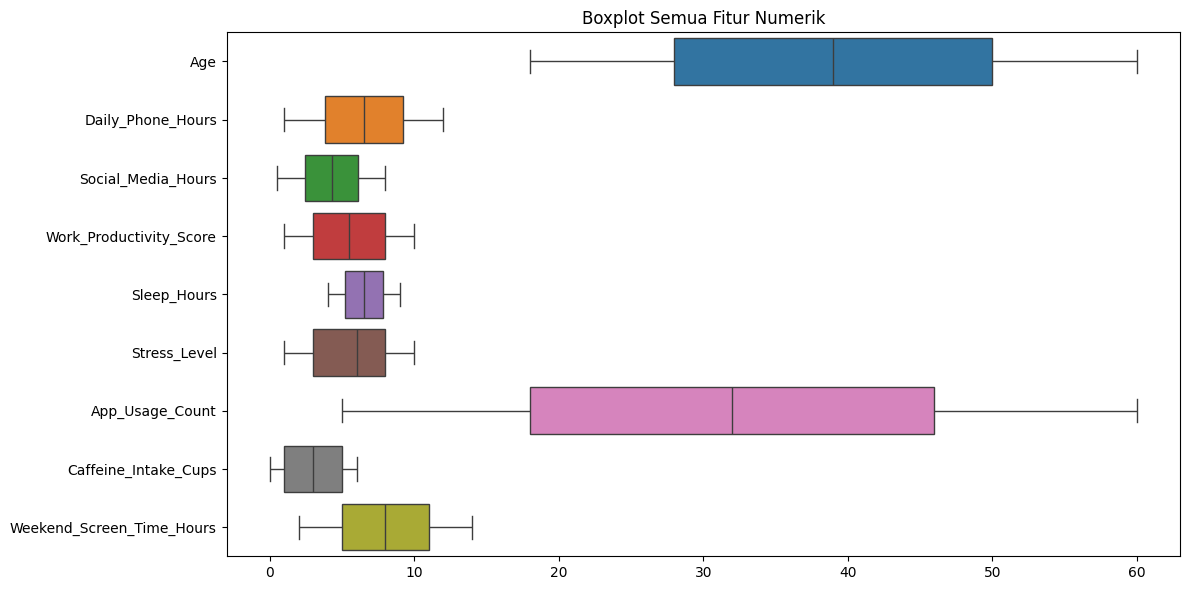

Jumlah outlier per kolom:
Age: 0
Daily_Phone_Hours: 0
Social_Media_Hours: 0
Work_Productivity_Score: 0
Sleep_Hours: 0
Stress_Level: 0
App_Usage_Count: 0
Caffeine_Intake_Cups: 0
Weekend_Screen_Time_Hours: 0


In [7]:
## Cek Outlier dengan Boxplot dan IQR
import matplotlib.pyplot as plt # kumpulan fungsi untuk visualisasi (plt.figure, plt.title, plt.show)
import seaborn as sns # library untuk visualisasi data yang lebih menarik (sns.boxplot)

# Ambil semua fitur numerik
num_cols = df.select_dtypes(include='number').columns
# bikin variable = ambil semua tipe data (numerik). kolom yang numerik

# Boxplot semua fitur numerik
plt.figure(figsize=(12, 6)) # ukuran figure 12x6 satuan inci
sns.boxplot(data=df[num_cols], orient='h') # tampilkan num_cols secara horizontal
plt.title("Boxplot Semua Fitur Numerik")
plt.tight_layout() # agar layoutnya rapih
plt.show() # tampilkan boxplot

# --- Cara hitung outlier pakai IQR ---
outlier_summary = {} # buat dictionary kosong untuk menyimpan jumlah outlier per kolom
for col in num_cols:
    Q1 = df[col].quantile(0.25) # hitung Q1, sebagai batas nilai 25% dari data
    Q3 = df[col].quantile(0.75) # hitung Q3, sebagai batas nilai 75% dari data
    IQR = Q3 - Q1 # hitung IQR, sebagai rentang antara Q1 dan Q3
    lower = Q1 - 1.5 * IQR #ini adalah batas bawah untuk outlier, nilai yang lebih kecil dari ini dianggap outlier
    upper = Q3 + 1.5 * IQR # ini adalah batas atas untuk outlier, nilai yang lebih besar dari ini dianggap outlier
    # kenapa 1.5? karena ini adalah aturan umum (John Tukey) untuk mendeteksi outlier, tapi bisa disesuaikan tergantung konteks data
    outliers = ((df[col] < lower) | (df[col] > upper)).sum() 
    # hitung jumlah outlier dengan menghitung berapa banyak nilai yang lebih kecil dari lower atau lebih besar dari upper
    outlier_summary[col] = outliers # simpan jumlah outlier untuk kolom ini di dictionary

print("Jumlah outlier per kolom:") 
for k, v in outlier_summary.items(): 
    # iterasi melalui dictionary outlier_summary dan print nama kolom (k) dan jumlah outlier (v)
    print(f"{k}: {v}")


### Lihat Data Stress Level

In [8]:
print (f'Cek macam-macam data stress level \n {df["Stress_Level"].unique()} \n')

Cek macam-macam data stress level 
 [ 4  1  3  7  2  9 10  8  5  6] 



### Pisahkan data train dan test

In [9]:
from sklearn.model_selection import train_test_split # import fungsi untuk membagi dataset menjadi data latih dan data uji

selected_feature = ["Age", "Daily_Phone_Hours", "Sleep_Hours"] # fitur yang dipilih untuk model
X = df[selected_feature] # fitur untuk menebak (hanya kolom yang dipilih)
y = df["Stress_Level"] -1 # target untuk ditebak (kolom stress_level) (kalau xgboost index 0, jadi perlu -1)

# cek distribusi kelas di target (y) dengan menghitung proporsi setiap kelas dan mengurutkannya berdasarkan indeks kelas
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify =y) 
# 42 didapat dari novel yang artinya adalah jawaban atas segalanya. kalau diulang? bisa. hasilnya? tetap sama
# x_train dan y_train adalah data latih, x_test dan y_test adalah data uji (tidak boleh dibalik urutannya)
# test_size=0.2 artinya 20% data akan digunakan untuk uji, 80% untuk latih
print(f"Jumlah data latih: {len(X_train)}")
print(f"Jumlah data uji: {len(X_test)}")

Stress_Level
4    5096
5    5076
1    5058
9    5031
2    5009
8    4993
7    4993
0    4940
6    4933
3    4871
Name: count, dtype: int64
Jumlah data latih: 40000
Jumlah data uji: 10000


### Encoding Data Kategori

In [10]:
# Encoding hanya kolom kategorik pada data train/test
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
# columns.tolist() untuk mengubah hasil select_dtypes menjadi list biasa
print("Kolom kategorik:", cat_cols)

# Lakukan one-hot encoding pada kolom kategorik, dengan dummy_na=True untuk menangani nilai NaN sebagai kategori tersendiri
if len(cat_cols) > 0:
    X_train = pd.get_dummies(X_train, columns=cat_cols)
    X_test = pd.get_dummies(X_test, columns=cat_cols)

    # Samakan kolom test ke struktur train (hindari mismatch saat prediksi)
    X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

# Cek shape setelah encoding
print("X_train:", X_train.shape) # cek jumlah baris dan kolom pada X_train setelah encoding
print("X_test :", X_test.shape) # cek jumlah baris dan kolom pada X_test setelah encoding

Kolom kategorik: []
X_train: (40000, 3)
X_test : (10000, 3)


Tidak ada yang di Encoding karena fitur yang dipilih ke-3 nya sudah number semua

### Train Data

In [11]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

model = XGBClassifier(
    objective='multi:softprob',   # multiclass # karena targetnya lebih dari 2 kelas
    num_class=10, # karena targetnya ada 10 kelas (0-9 setelah dikurangi 1)
    learning_rate=0.05, # karena ini adalah kecepatan belajar, semakin kecil semakin lambat tapi bisa lebih akurat (default 0.1)
    n_estimators=200, # jumlah pohon yang akan dibuat, semakin banyak bisa lebih akurat tapi juga bisa overfitting (default 100)
    max_depth=4, # karena ini adalah kedalaman pohon, semakin dalam bisa lebih akurat tapi juga bisa overfitting (default 6)
    min_child_weight=1, # karena ini adalah jumlah minimum sampel yang dibutuhkan untuk membuat split di pohon, semakin besar bisa lebih konservatif tapi juga bisa underfitting (default 1)
    gamma=0, # karena ini adalah parameter regularisasi yang mengontrol seberapa besar penurunan loss yang dibutuhkan untuk membuat split baru, semakin besar bisa lebih konservatif tapi juga bisa underfitting (default 0)
    subsample=0.8, # karena ini adalah proporsi sampel yang digunakan untuk membangun setiap pohon, semakin kecil bisa lebih konservatif tapi juga bisa underfitting (default 1)
    colsample_bytree=0.8,   # karena ini adalah proporsi fitur yang digunakan untuk membangun setiap pohon, semakin kecil bisa lebih konservatif tapi juga bisa underfitting (default 1)
    reg_alpha=0.1, # karena ini adalah parameter regularisasi L1 yang mengontrol seberapa besar penalti L1 yang diterapkan pada bobot, semakin besar bisa lebih konservatif tapi juga bisa underfitting (default 0)
    reg_lambda=0.1, # karena ini adalah parameter regularisasi L2 yang mengontrol seberapa besar penalti L2 yang diterapkan pada bobot, semakin besar bisa lebih konservatif tapi juga bisa underfitting (default 0)
    eval_metric='mlogloss', # karena ini adalah metrik evaluasi yang digunakan untuk memantau kinerja model selama pelatihan, mlogloss cocok untuk klasifikasi multi-kelas (default 'logloss' untuk binary classification)
    random_state=42 # untuk memastikan hasil yang konsisten saat menjalankan ulang kode (default None
)

model.fit(
    X_train, y_train, # latih model dengan data latih
    eval_set=[(X_test, y_test)], # gunakan data uji sebagai set evaluasi untuk memantau kinerja model selama pelatihan
    verbose=False # untuk menonaktifkan output log selama pelatihan (default True
)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


### Evaluasi Model

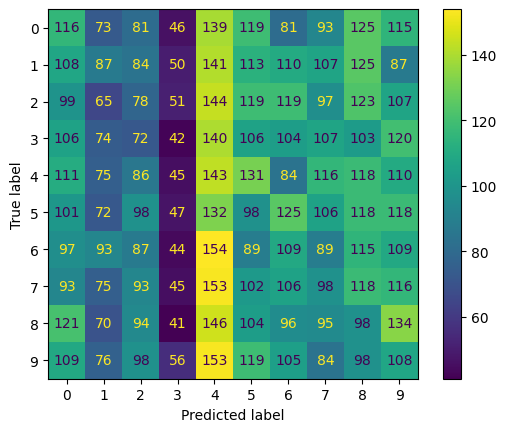

              precision    recall  f1-score   support

           0       0.11      0.12      0.11       988
           1       0.11      0.09      0.10      1012
           2       0.09      0.08      0.08      1002
           3       0.09      0.04      0.06       974
           4       0.10      0.14      0.12      1019
           5       0.09      0.10      0.09      1015
           6       0.10      0.11      0.11       986
           7       0.10      0.10      0.10       999
           8       0.09      0.10      0.09       999
           9       0.10      0.11      0.10      1006

    accuracy                           0.10     10000
   macro avg       0.10      0.10      0.10     10000
weighted avg       0.10      0.10      0.10     10000



In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay 
# import fungsi untuk membuat confusion matrix dan menampilkannya

y_pred = model.predict(X_test) # prediksi kelas untuk data uji menggunakan model yang sudah dilatih
cm = confusion_matrix(y_test, y_pred) # hitung confusion matrix dengan membandingkan kelas sebenarnya (y_test) dengan kelas yang diprediksi (y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm) 
# buat objek ConfusionMatrixDisplay dengan confusion matrix yang sudah dihitung
disp.plot() # tampilkan confusion matrix sebagai plot
plt.show() # tampilkan confusion matrix

from sklearn.metrics import classification_report 
# import fungsi untuk membuat classification report yang berisi metrik evaluasi seperti precision, recall, f1-score, dan support untuk setiap kelas
print(classification_report(y_test, y_pred)) 
# print classification report untuk mengevaluasi kinerja model pada data uji dengan membandingkan kelas sebenarnya (y_test) dengan kelas yang diprediksi (y_pred)



### Cek Korelasi Antar Fitur

Matriks korelasi:


,Age,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
Age,1.000000,0.006147,-0.005589,-0.003480,-0.000640,-0.001512,-0.009490,-0.005242,0.003127
Daily_Phone_Hours,0.006147,1.000000,0.000591,-0.002404,-0.003434,-0.002762,0.004670,0.006465,-0.003123
Social_Media_Hours,-0.005589,0.000591,1.000000,0.003625,-0.000871,-0.002721,0.001831,0.009161,-0.008570
Work_Productivity_Score,-0.003480,-0.002404,0.003625,1.000000,0.003243,0.009786,0.001125,0.001253,-0.005343
Sleep_Hours,-0.000640,-0.003434,-0.000871,0.003243,1.000000,0.004691,0.000999,0.004251,-0.006457
Stress_Level,-0.001512,-0.002762,-0.002721,0.009786,0.004691,1.000000,-0.001272,0.001718,0.002671
App_Usage_Count,-0.009490,0.004670,0.001831,0.001125,0.000999,-0.001272,1.000000,-0.000096,-0.000530
Caffeine_Intake_Cups,-0.005242,0.006465,0.009161,0.001253,0.004251,0.001718,-0.000096,1.000000,0.002682
Weekend_Screen_Time_Hours,0.003127,-0.003123,-0.008570,-0.005343,-0.006457,0.002671,-0.000530,0.002682,1.000000


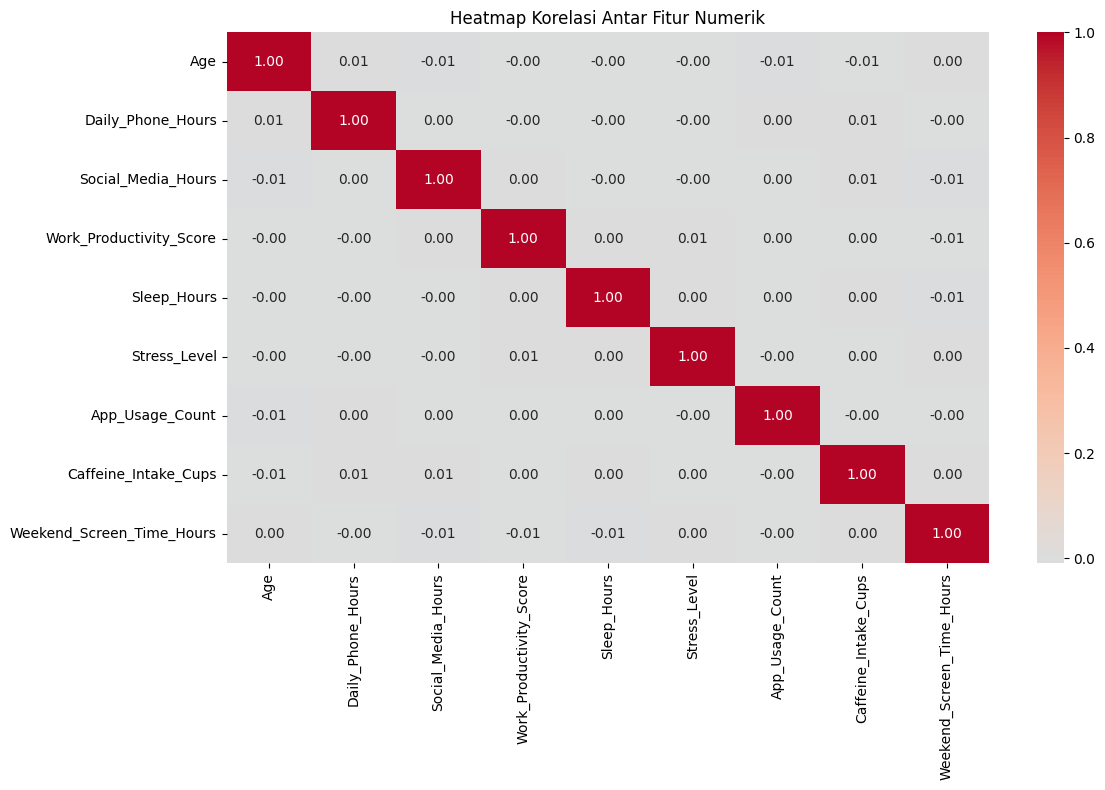

10 pasangan fitur dengan korelasi terkuat:


Stress_Level               Work_Productivity_Score      0.009786
Work_Productivity_Score    Stress_Level                 0.009786
Age                        App_Usage_Count             -0.009490
App_Usage_Count            Age                         -0.009490
Social_Media_Hours         Caffeine_Intake_Cups         0.009161
Caffeine_Intake_Cups       Social_Media_Hours           0.009161
Weekend_Screen_Time_Hours  Social_Media_Hours          -0.008570
Social_Media_Hours         Weekend_Screen_Time_Hours   -0.008570
Caffeine_Intake_Cups       Daily_Phone_Hours            0.006465
Daily_Phone_Hours          Caffeine_Intake_Cups         0.006465
dtype: float64

In [13]:
import numpy as np # import library untuk operasi numerik (np.random.seed)

# Cek korelasi antar fitur numerik
corr_matrix = df.select_dtypes(include="number").corr()

print("Matriks korelasi:")
display(corr_matrix)

# Visualisasi heatmap korelasi
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Heatmap Korelasi Antar Fitur Numerik")
plt.tight_layout()
plt.show()

# Tampilkan pasangan fitur dengan korelasi terkuat (tanpa diagonal)
corr_pairs = (
    corr_matrix.where(~np.eye(corr_matrix.shape[0], dtype=bool))
    .stack()
    .sort_values(key=lambda x: x.abs(), ascending=False)
)
print("10 pasangan fitur dengan korelasi terkuat:")
display(corr_pairs.head(10))

### Hasil tidak memuaskan karena dataset hasil generate dan fiturnya tidak memiliki korelasi